In [2]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# Custom utilities
import sys
sys.path.append('utils')

from data_loader import DataLoader
from visualization import BehavioralVisualizer, NeuralVisualizer, create_utah_array_layout

print("✓ All imports successful!")
print("Python version:", sys.version)


Neuroshare not available. Will use Neo for .ns6 files.
✓ All imports successful!
Python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [3]:
# Configure file paths
NS6_FILE_PATH = r"D:\Data\ScienceCorp\neural.ns6"  # Update this path
CSV_FILE_PATH = r"D:\Data\ScienceCorp\actions.csv"  # Update this path

# Check if files exist
import os
ns6_exists = os.path.exists(NS6_FILE_PATH)
csv_exists = os.path.exists(CSV_FILE_PATH)

print(f"NS6 file exists: {ns6_exists}")
print(f"CSV file exists: {csv_exists}")

if not ns6_exists:
    print(f"⚠️  Neural data file not found at: {NS6_FILE_PATH}")
    print("Please update NS6_FILE_PATH with the correct path to your .ns6 file")
    
if not csv_exists:
    print(f"⚠️  Behavioral data file not found at: {CSV_FILE_PATH}")
    print("Please update CSV_FILE_PATH with the correct path to your .csv file")


NS6 file exists: True
CSV file exists: True


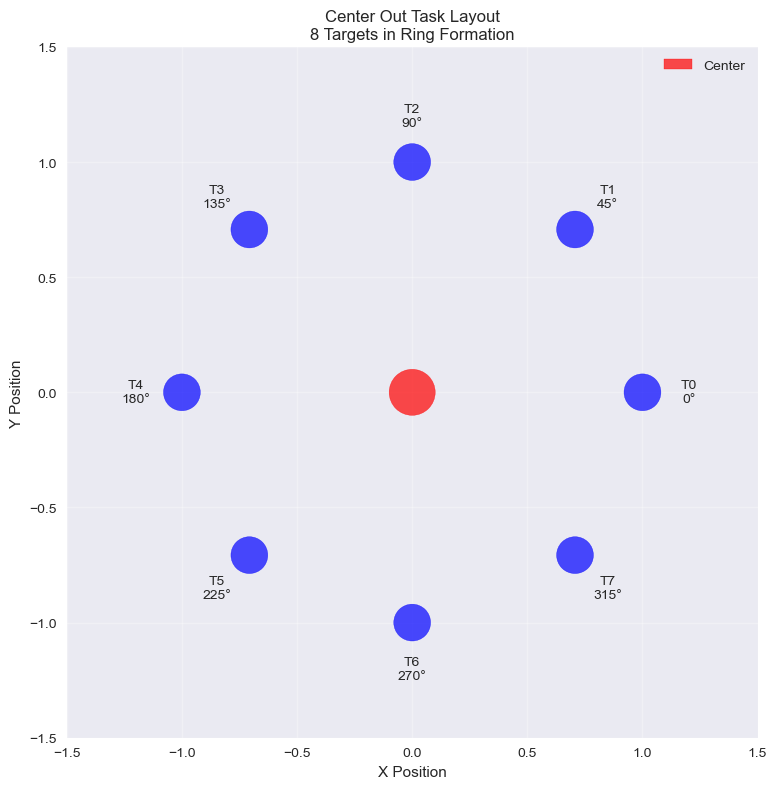

Center Out Task Layout:
- 8 targets arranged in a ring
- Red center: starting position
- Blue circles: target positions
- Each target has a specific direction (0°, 45°, 90°, etc.)


In [4]:
# Initialize behavioral visualizer
behavioral_viz = BehavioralVisualizer()

# Plot the Center Out task layout
fig = behavioral_viz.plot_center_out_layout(figsize=(8, 8))
plt.show()

print("Center Out Task Layout:")
print("- 8 targets arranged in a ring")
print("- Red center: starting position")
print("- Blue circles: target positions")
print("- Each target has a specific direction (0°, 45°, 90°, etc.)")


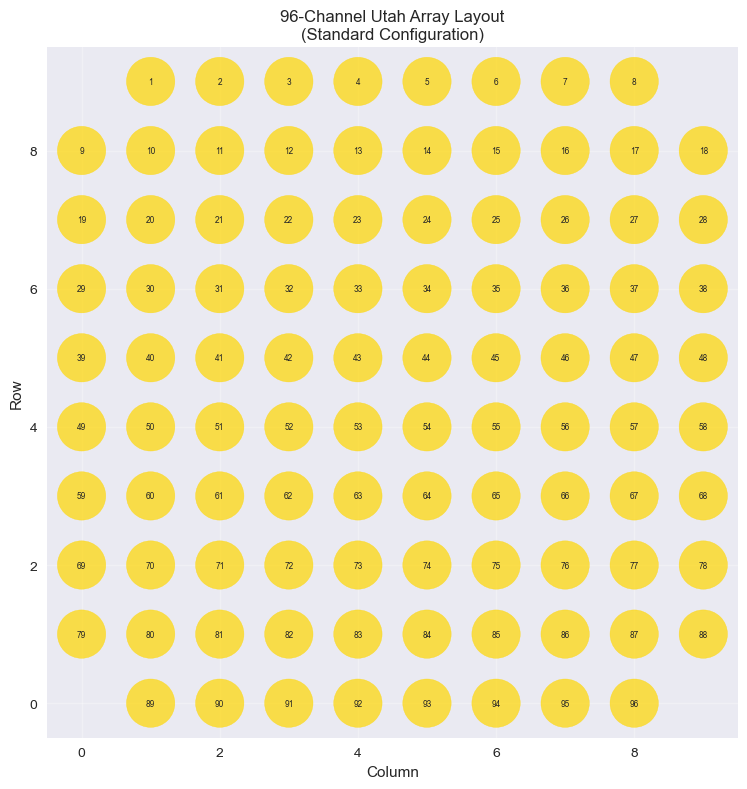

Utah Array Configuration:
- 96 electrodes in 10x10 grid (minus 4 corners)
- Implanted in M1 hand knob area
- Standard channel mapping
- Each electrode samples local field potential and spikes


In [5]:
# Plot Utah array layout
fig = create_utah_array_layout(figsize=(10, 8))
plt.show()

print("Utah Array Configuration:")
print("- 96 electrodes in 10x10 grid (minus 4 corners)")
print("- Implanted in M1 hand knob area")
print("- Standard channel mapping")
print("- Each electrode samples local field potential and spikes")


In [6]:
# Initialize data loader
loader = DataLoader(ns6_file_path=NS6_FILE_PATH, csv_file_path=CSV_FILE_PATH)

# Load behavioral data first (usually faster)
print("Loading behavioral data...")
behavioral_data = loader.load_behavioral_data()

if behavioral_data is not None:
    print("\nBehavioral Data Preview:")
    print(behavioral_data.head())
    print("\nData Info:")
    print(behavioral_data.info())
else:
    print("❌ Failed to load behavioral data")


Loading behavioral data...
Behavioral data loaded successfully!
Shape: (58298, 8)
Columns: ['timestamp', 'velocity_x', 'velocity_y', 'trial_start', 'trial_win', 'trial_lose', 'num_targets', 'target_index']

Behavioral Data Preview:
                      timestamp  velocity_x  velocity_y  trial_start  \
0 1970-01-01 00:00:01.742937748         0.0         0.0         True   
1 1970-01-01 00:00:01.742937748         0.0         0.0        False   
2 1970-01-01 00:00:01.742937748         0.0         0.0        False   
3 1970-01-01 00:00:01.742937748         0.0         0.0        False   
4 1970-01-01 00:00:01.742937748         0.0         0.0        False   

   trial_win  trial_lose  num_targets  target_index  
0      False       False            8             4  
1      False       False            8             4  
2      False       False            8             4  
3      False       False            8             4  
4      False       False            8             4  

Data Info:

In [7]:
# Load neural data (this may take a while)
print("Loading neural data... (this may take some time)")
neural_data = loader.load_neural_data()

if neural_data is not None:
    print("\nNeural Data Summary:")
    print(f"Data shape: {neural_data['raw_data'].shape}")
    print(f"Sampling rate: {loader.metadata['sampling_rate']} Hz")
    print(f"Duration: {loader.metadata['duration']:.2f} seconds")
    print(f"Number of channels: {loader.metadata['n_channels']}")
    print(f"Data type: {neural_data['raw_data'].dtype}")
    print(f"Memory usage: {neural_data['raw_data'].nbytes / 1024**2:.1f} MB")
else:
    print("❌ Failed to load neural data")


Loading neural data... (this may take some time)
Neural data loaded successfully using Neo!
Sampling rate: 30000.0 Hz
Number of channels: 96
Duration: 1501.14 seconds
Data shape: (45034200, 96)

Neural Data Summary:
Data shape: (45034200, 96)
Sampling rate: 30000.0 Hz
Duration: 1501.14 seconds
Number of channels: 96
Data type: float32
Memory usage: 16492.0 MB
